In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [5]:
df = pd.read_csv('data.csv')
df.head()

,feature1,feature2,feature3,label
0,1.0,1.2,0.8,0
1,1.5,1.0,1.3,0
2,2.0,1.8,1.5,0
3,2.3,2.1,2.0,0
4,2.8,2.5,2.2,0


In [6]:
custom_palette = {
    0: (245/255, 88/255, 159/255),  # Pink
    1: (7/255, 94/255, 181/255)     # Blue
}

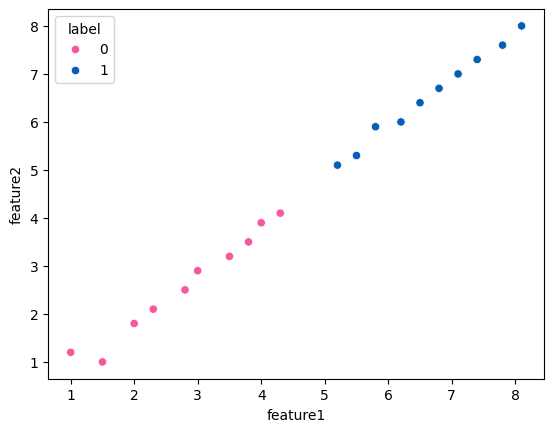

In [7]:
sns.scatterplot(data=df, x="feature1", y="feature2", hue="label", palette=custom_palette)
plt.show()

In [8]:
from sklearn.neighbors import KNeighborsClassifier

data = df[['feature1', 'feature2', 'feature3']].values
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(data, df["label"])

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


[0 1 1]


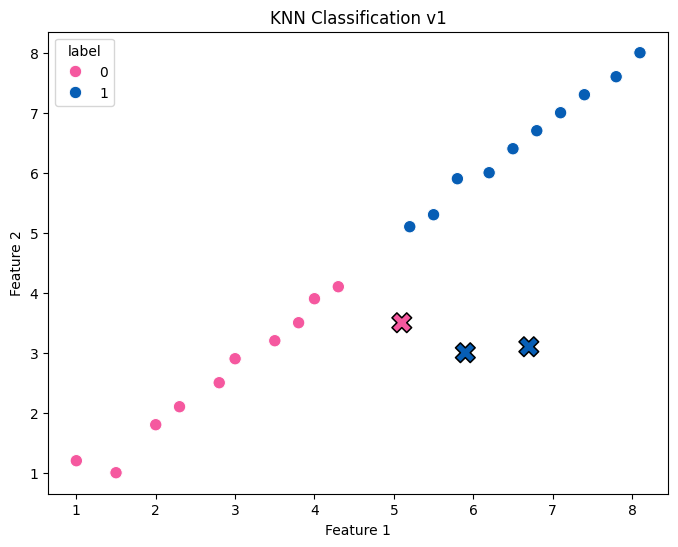

In [9]:
new_data = [
    [5.1, 3.5, 1.4],
    [6.7, 3.1, 4.7],
    [5.9, 3.0, 5.1]
]

predictions = knn.predict(new_data)
print(predictions)

# DataFrame for new samples
new_data_df = pd.DataFrame(
    new_data,
    columns=['feature1', 'feature2', 'feature3']
)
new_data_df['prediction'] = predictions

# Plot training data
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='feature1',
    y='feature2',
    hue='label',
    palette=custom_palette,
    s=80
)

# New samples
sns.scatterplot(
    data=new_data_df,
    x='feature1',
    y='feature2',
    hue='prediction',
    palette=custom_palette,
    marker='X',
    s=200,
    edgecolor='black',
    legend=False
)

plt.title("KNN Classification v1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Two features were classified as label 1 and remaining one was classified as label 0

[1 1 0]


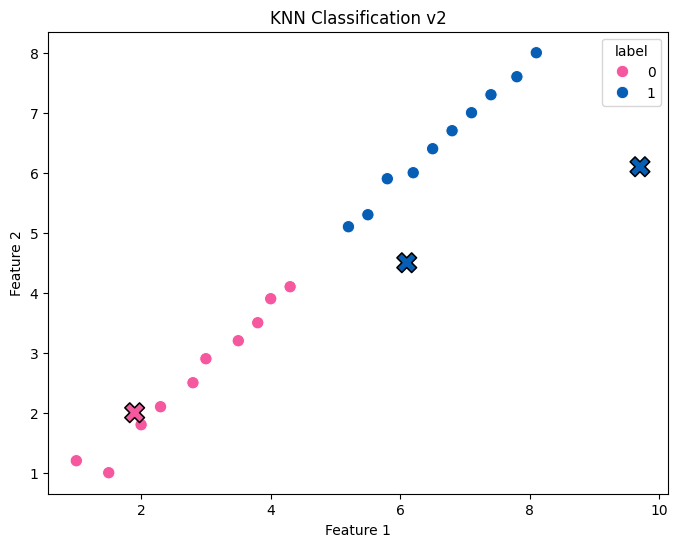

In [10]:
data = df[['feature1', 'feature2', 'feature3']].values
knn = KNeighborsClassifier(n_neighbors=4)

knn.fit(data, df["label"])

new_data = [[6.1, 4.5, 9.4], [9.7, 6.1, 3.7], [1.9, 2.0, 8.1]]
predictions = knn.predict(new_data)
print(predictions)  

new_data_df = pd.DataFrame(
    new_data,
    columns=['feature1', 'feature2', 'feature3']
)
new_data_df['prediction'] = predictions

# Plot training data
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='feature1',
    y='feature2',
    hue='label',
    palette=custom_palette,
    s=80
)

# New samples
sns.scatterplot(
    data=new_data_df,
    x='feature1',
    y='feature2',
    hue='prediction',
    palette=custom_palette,
    marker='X',
    s=200,
    edgecolor='black',
    legend=False
)

plt.title("KNN Classification v2")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


By changing n_neighbors=4, we can see a change, all 2 new points were classified with label 1 and last one with label 0

#### Conclusions

The K-Nearest Neighbours (KNN) algorithm successfully classified new observations based on the labels of the nearest training samples in the feature space. The experiment demonstrated that the choice of the `n_neighbors` parameter has a direct impact on the classification results.

With `n_neighbors = 3`, two new observations were assigned to class 1, while one observation was classified as class 0. After increasing the number of neighbours to `n_neighbors = 4`, the classification remained stable for one observation but changed for another, illustrating how considering more neighbouring points can influence the predicted class.

This experiment highlights several important characteristics of KNN:
- KNN is a simple, intuitive, and non-parametric supervised learning algorithm.
- Predictions depend heavily on the local distribution of the training data.
- The value of **k** significantly affects the decision boundary and model behaviour.
- Selecting an appropriate value of **k** is essential to balance sensitivity to noise (small *k*) and excessive smoothing (large *k*).

Overall, the notebook demonstrates how KNN performs classification and how tuning a single hyperparameter can alter the model's predictions, reinforcing the importance of model evaluation and parameter selection in machine learning.